# Data Exploration

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv(r"C:\Users\DELL\Desktop\Data Science\IEP\netflix_titles.csv")

In [16]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
df.shape

(8807, 12)

In [18]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [19]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

# Data Cleaning

## Null Values

In [20]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [21]:
# fill  null values

In [22]:
df["director"]=df['director'].fillna(df['director'].mode()[0])
df["cast"]=df['cast'].fillna(df['cast'].mode()[0])
df["country"]=df['country'].fillna(df['country'].mode()[0])
df["rating"]=df['rating'].fillna(df['rating'].mode()[0])
df["duration"]=df['duration'].fillna(df['duration'].mode()[0])

In [23]:
df=df.dropna(subset=['date_added'])

In [24]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Duplicate Values

In [25]:
print(df.duplicated().sum())

0


# Outlier Analysis

In [26]:
import numpy as np
df.select_dtypes(include=np.number)

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021
...,...
8802,2007
8803,2018
8804,2009
8805,2006


In [27]:
import seaborn as sns

<Axes: >

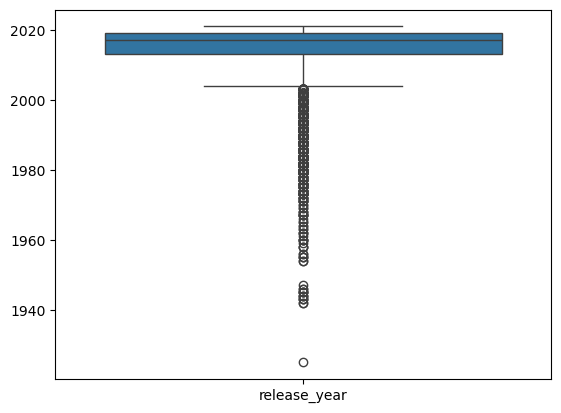

In [28]:
sns.boxplot([df["release_year"]])

# IQR

In [29]:
a=df.select_dtypes(include=np.number)

In [30]:

for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)

In [31]:
IQR=q3-q1

In [32]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [33]:
outliers=((a[i]>Uw)|(a[i]<Lw))

In [34]:
outliers.sum()

np.int64(717)

# Data Analysis

In [35]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Text(0.5, 1.0, 'Movies vs TV Shows')

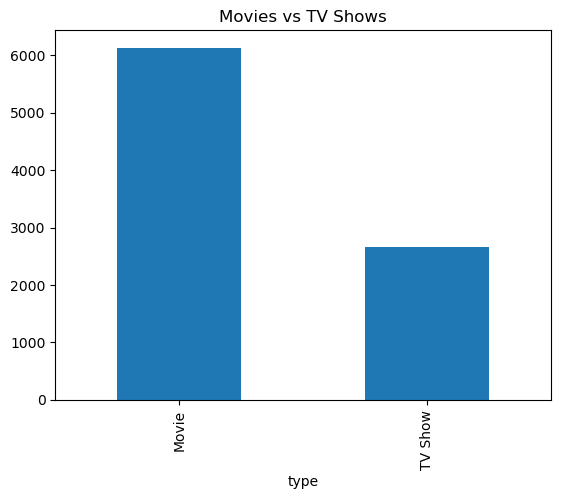

In [39]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")

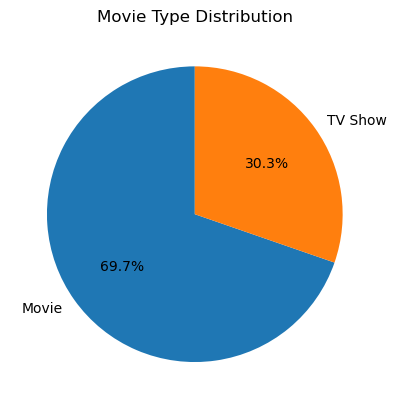

In [40]:
movie_type_title = df.groupby('type')['title'].count()

plt.pie(movie_type_title, labels=movie_type_title.index, autopct='%.1f%%', startangle=90)

plt.title('Movie Type Distribution')
plt.show()

<Axes: xlabel='country'>

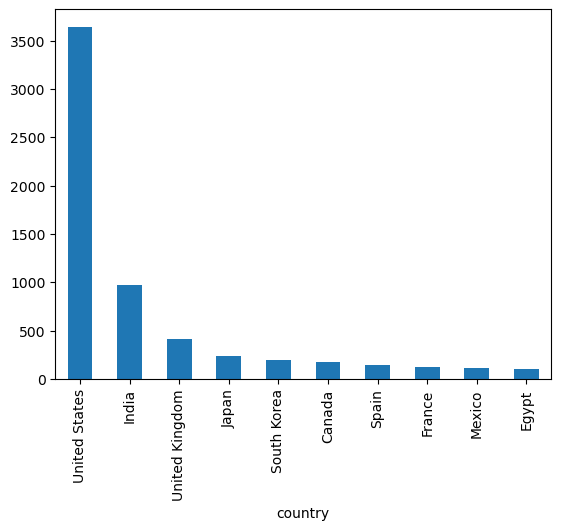

In [41]:
df['country'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='listed_in'>

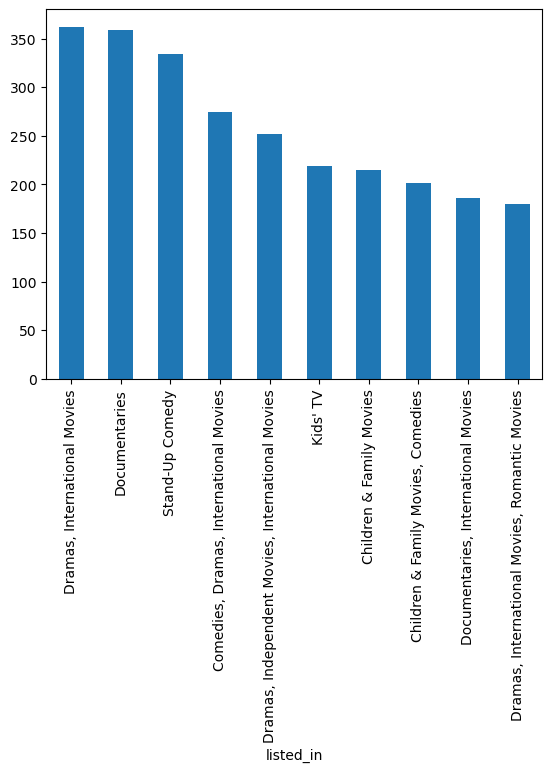

In [42]:
df['listed_in'].value_counts().head(10).plot(kind='bar')

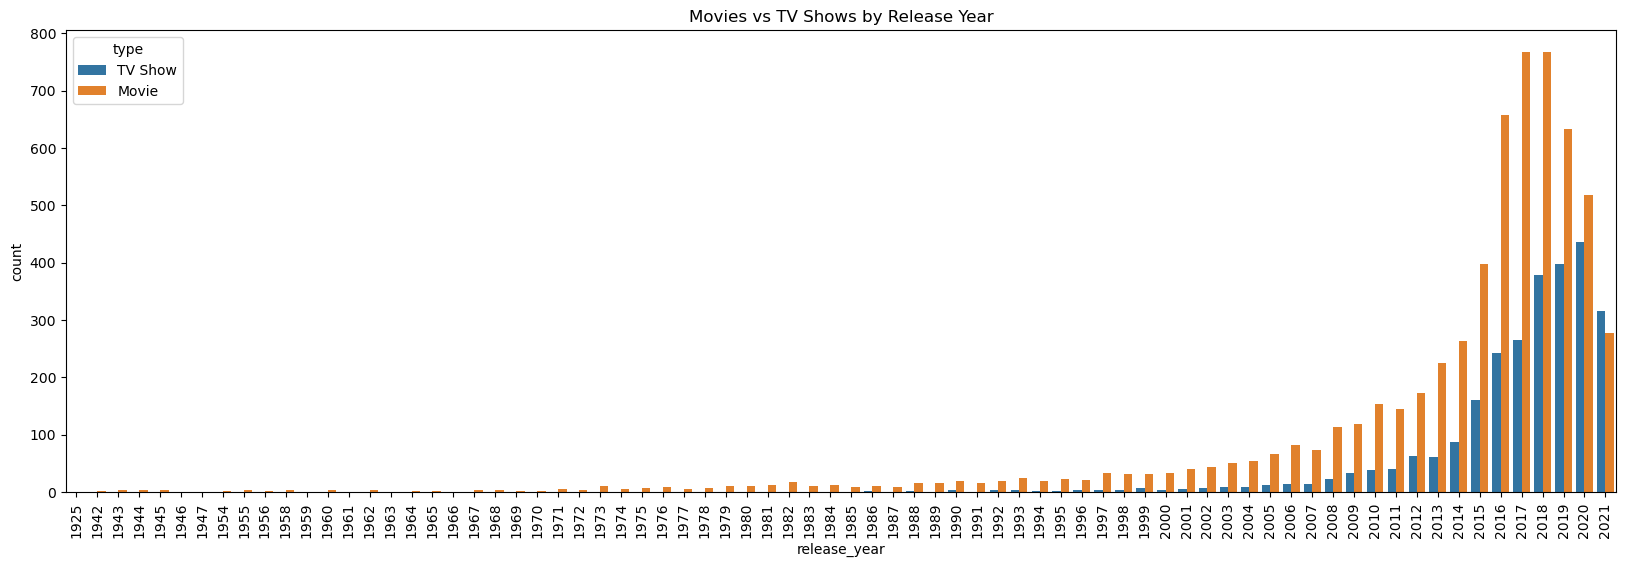

In [43]:
plt.figure(figsize=(20,6))
sns.countplot(x='release_year', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows by Release Year")
plt.show()

<Axes: xlabel='release_year'>

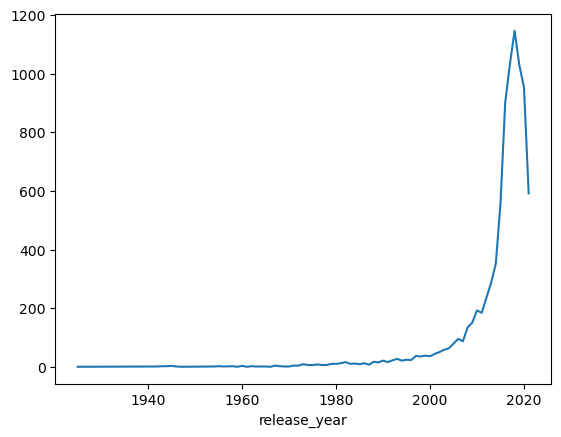

In [44]:
df['release_year'].value_counts().sort_index().plot()

<Axes: xlabel='rating'>

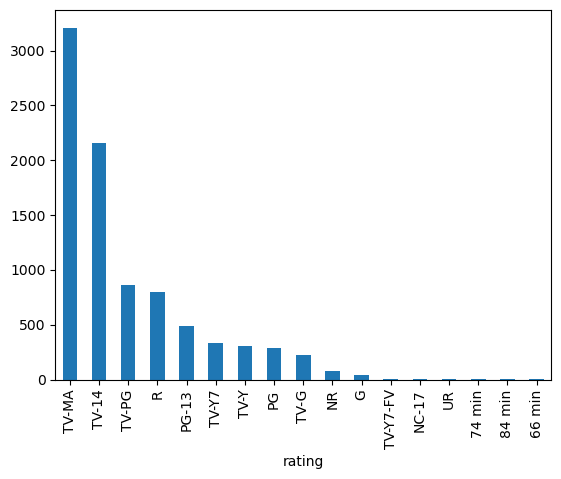

In [45]:
df['rating'].value_counts().plot(kind='bar')

<Axes: xlabel='date_added'>

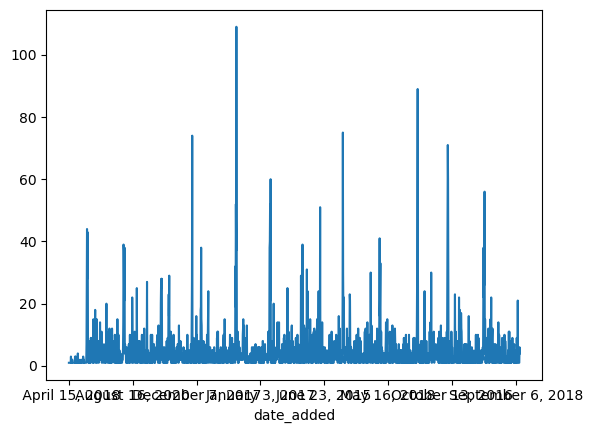

In [46]:
df['date_added'].value_counts().sort_index().plot()

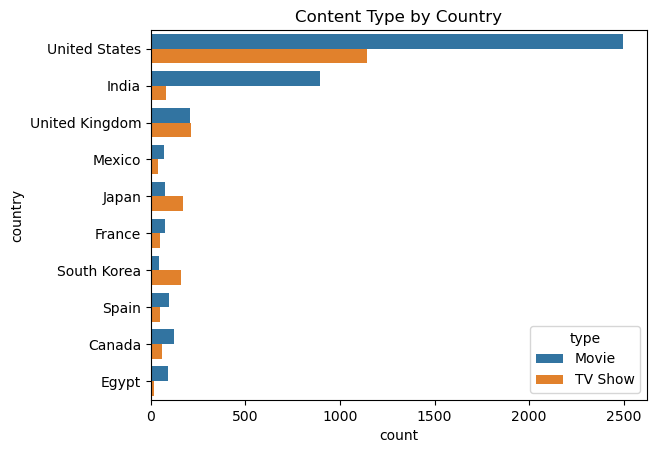

In [47]:
top_countries = df['country'].value_counts().head(10).index
filtered = df[df['country'].isin(top_countries)]

sns.countplot(y='country', hue='type', data=filtered)
plt.title("Content Type by Country")
plt.show()

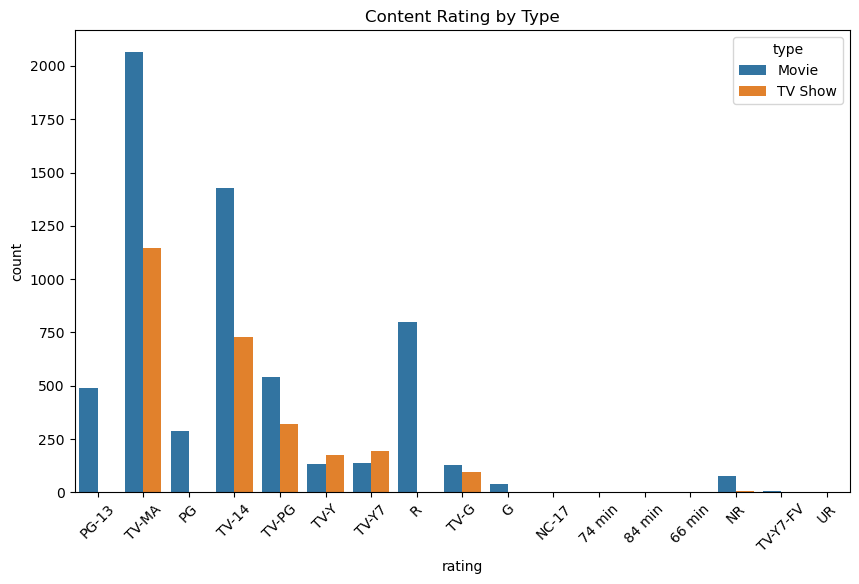

In [48]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating', hue='type', data=df)
plt.xticks(rotation=45)
plt.title("Content Rating by Type")
plt.show()

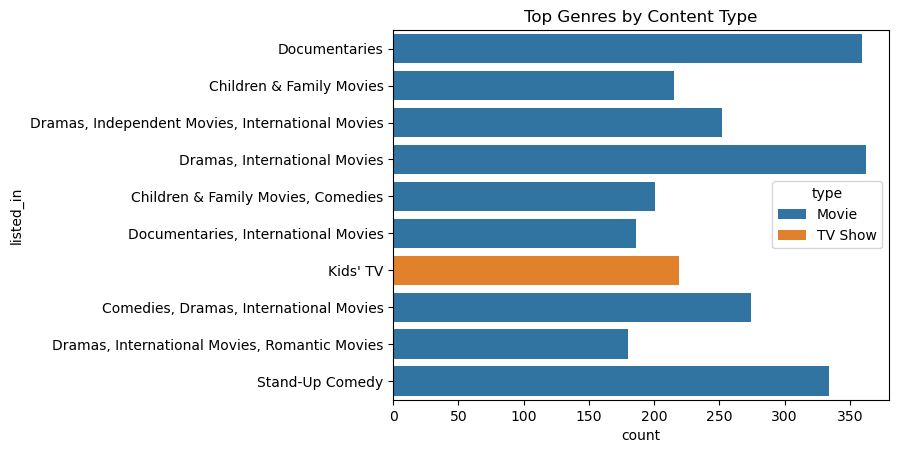

In [49]:
top_genres = df['listed_in'].value_counts().head(10).index
genre_df = df[df['listed_in'].isin(top_genres)]

sns.countplot(y='listed_in', hue='type', data=genre_df)
plt.title("Top Genres by Content Type")
plt.show()

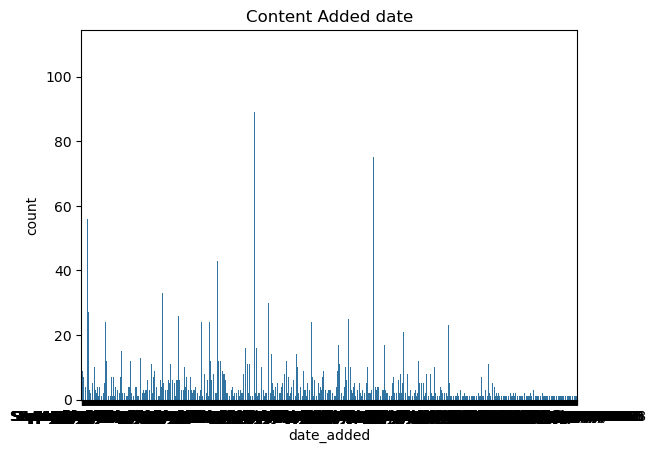

In [50]:
sns.countplot(x='date_added', data=df)
plt.title("Content Added date")
plt.show()

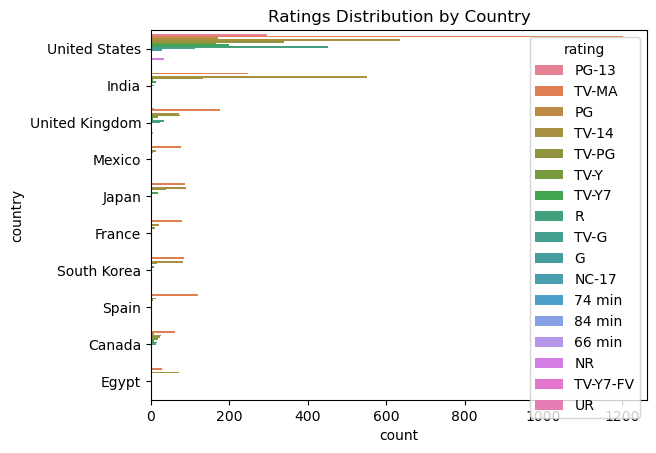

In [51]:
sns.countplot(y='country', hue='rating', data=filtered)
plt.title("Ratings Distribution by Country")
plt.show()

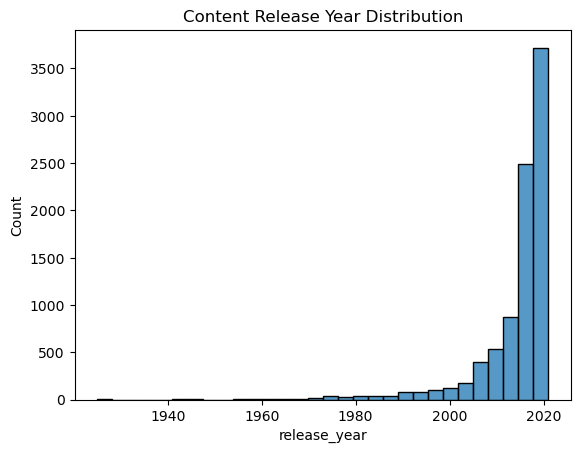

In [52]:
sns.histplot(df['release_year'], bins=30)
plt.title("Content Release Year Distribution")
plt.show()

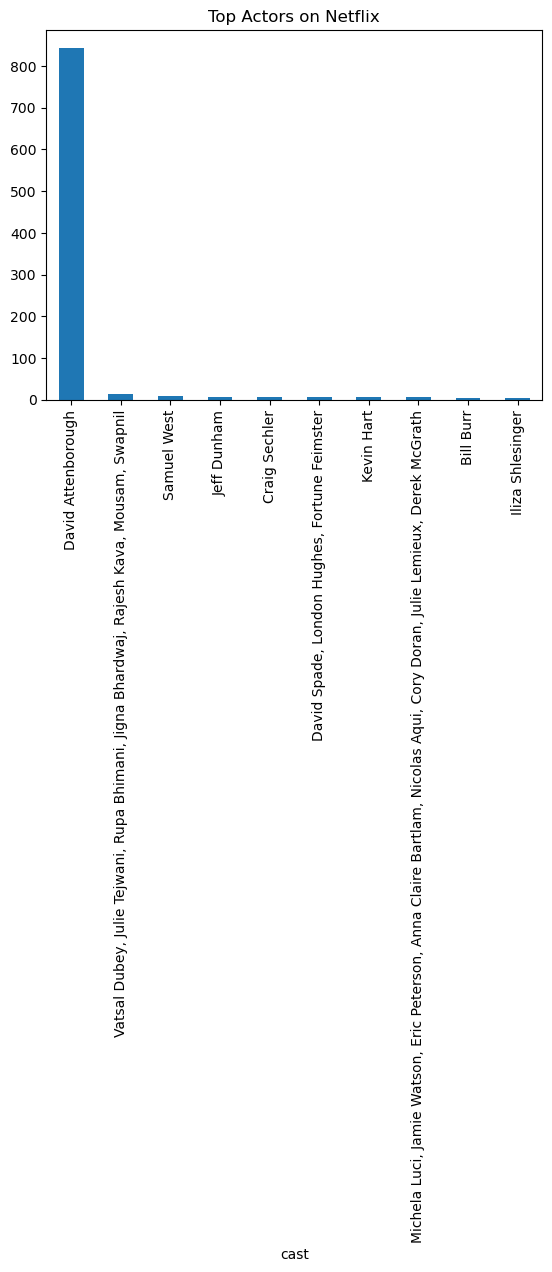

In [53]:
top_cast = df['cast'].value_counts().head(10)

top_cast.plot(kind='bar')
plt.title("Top Actors on Netflix")
plt.show()

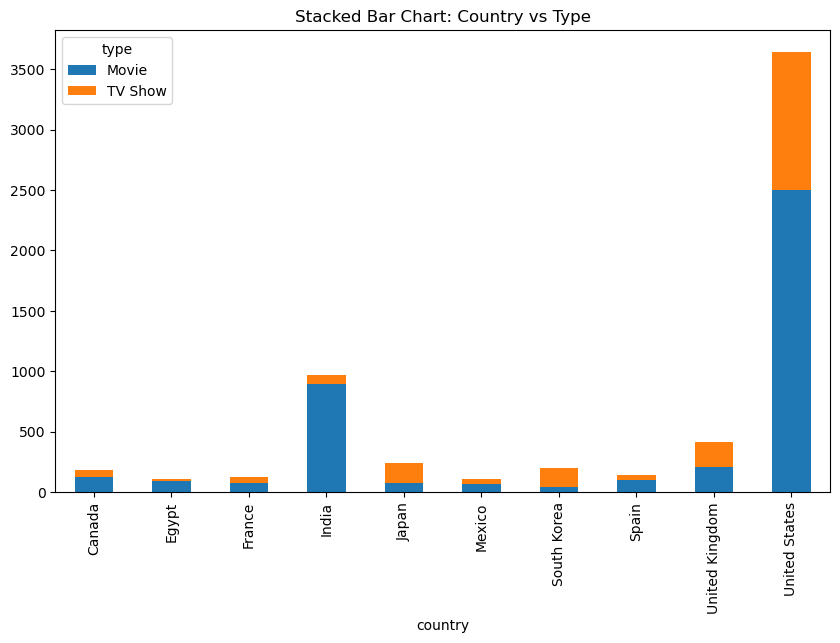

In [54]:
ct = pd.crosstab(filtered['country'], filtered['type'])

ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Stacked Bar Chart: Country vs Type")
plt.show()

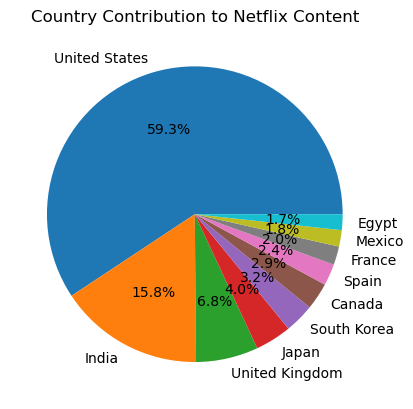

In [55]:
country_counts = df['country'].value_counts().head(10)

plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%')
plt.title("Country Contribution to Netflix Content")
plt.show()